# BNPL Project — Analysis 3
## OLS Linear Probability Model (Rigorous WLS + HC3)

In [1]:
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

print("Loading data...")
z = zipfile.ZipFile('../data/raw/public2024.csv.zip')
df = pd.read_csv(z.open('public2024.csv'), low_memory=False)

# Recreate vulnerability score for this notebook (or load if we saved it, but we'll recreate for standalone execution)
df['bnpl_use'] = df['BNPL1'].apply(lambda x: 1 if x == 'Yes' else 0)

df['age_cat'] = df['ppagecat']
df['income_cat'] = df['inc_4cat_50k']
df['race_cat'] = df['race_5cat']
df['educ_cat'] = df['educ_4cat']

# Re-run a simplified PCA here to get vulnerability_score since we didn't save it to a file
df['fragile_EF1'] = df['EF1'].apply(lambda x: 1 if x == 'No' else 0)
df['fragile_okay'] = df['atleast_okay'].apply(lambda x: 1 if x == 'No' else 0)
df['fragile_E2'] = df['E2'].apply(lambda x: 1 if x == 'Yes' else 0)
df['fragile_K0'] = df['K0'].apply(lambda x: 1 if x == 'Yes' else 0)

fragility_cols = ['fragile_EF1', 'fragile_okay', 'fragile_E2', 'fragile_K0']
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
sub = df.dropna(subset=fragility_cols + ['weight'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(sub[fragility_cols])
pca = PCA(n_components=1)
sub['vulnerability_score'] = pca.fit_transform(X_scaled)

# Ensure positive means more fragile (if EF1 etc are positive, check correlation)
if sub[['vulnerability_score', 'fragile_EF1']].corr().iloc[0,1] < 0:
    sub['vulnerability_score'] *= -1

df = df.merge(sub[['vulnerability_score']], left_index=True, right_index=True, how='left')


Loading data...


### Weighted Least Squares (WLS) with HC3 Robust Standard Errors

                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                   0.1665      0.023      7.266      0.000       0.122       0.211
age_cat[T.25-34]                                            0.0148      0.017      0.859      0.390      -0.019       0.048
age_cat[T.35-44]                                           -0.0036      0.017     -0.204      0.838      -0.038       0.031
age_cat[T.45-54]                                           -0.0267      0.018     -1.518      0.129      -0.061       0.008
age_cat[T.55-64]                                           -0.0469      0.017     -2.774      0.006      -0.080      -0.014
age_cat[T.65-74]                                           -0.0891      0.016     -5.464      0.000      -0.121      -0.057
age_cat[

<Figure size 1000x600 with 0 Axes>

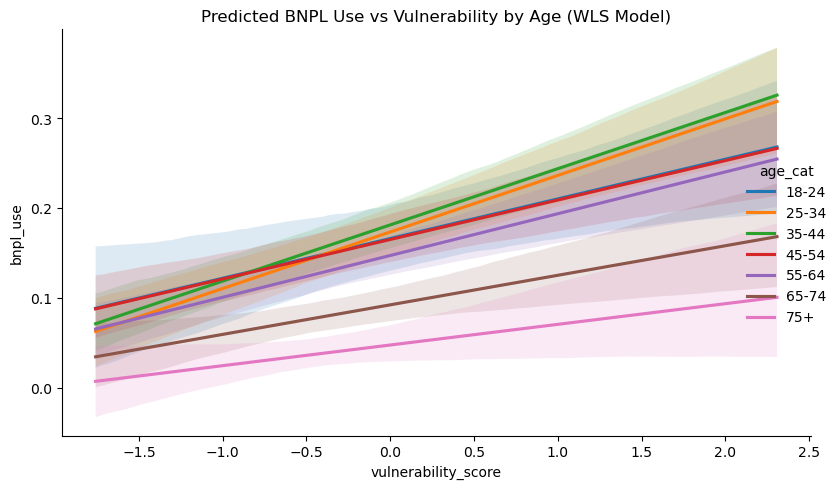

In [2]:
demographics = ['age_cat', 'income_cat', 'race_cat', 'educ_cat']
for col in demographics:
    df[col] = df[col].astype('category')

# Drop NA for regression
df_reg = df.dropna(subset=['bnpl_use', 'vulnerability_score', 'weight'] + demographics)

# Fit WLS model using survey weights
formula = 'bnpl_use ~ vulnerability_score * age_cat + income_cat + race_cat + educ_cat'

# We use smf.wls to account for the survey weights and cov_type='HC3' to correct for heteroskedasticity 
# inherent in the Linear Probability Model.
model = smf.wls(formula=formula, data=df_reg, weights=df_reg['weight']).fit(cov_type='HC3')
print(model.summary().tables[1])

plt.figure(figsize=(10,6))
sns.lmplot(x='vulnerability_score', y='bnpl_use', hue='age_cat', data=df_reg.sample(5000, random_state=42), scatter=False, aspect=1.5)
plt.title('Predicted BNPL Use vs Vulnerability by Age (WLS Model)')
plt.tight_layout()
plt.savefig('../figures/ols_interaction_age_wls.png')
plt.show()
